## 1. Data Inspection & Cleaniness Assessment
In this section, the raw dataset is loaded into Jupyter for inspection of overall quality. Key Focal points are searching for missing values, ensuring data looks correct (e.g. no outliers in numerical data) and ensuring correct data types across all columns.
### Comments:
* **Missing Values:** The dataset has no missing values.
* **Zero-Variance Columns:** Preliminary checks revealed three columns (EmployeeCount, Over18, StandardHours) that contain identical values across all rows. These provide zero statisical variance and will be dropped.
* **Unique Identifier:** EmployeeNumber is a unique key per row with no predictive value.

In [51]:
# Here we are importing all necessary packages, this section will update across the lifecycle of the project as more analyses are completed.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [52]:
# Importing in data using pandas read_csv function
attrition_ibm = pd.read_csv('https://raw.githubusercontent.com/dolphisj/Attrition_data/main/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [53]:
# This ensures all columns are displayed when viewing the data using methods such as .head() and .tail().
pd.set_option('display.max_columns', None)

In [54]:
# viewing the first 15 rows of data to get a sense of what the data looks like
attrition_ibm.head(15)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [55]:
# Here we are viewing the data types of the data ensuring datatypes make sense. given the column values.
attrition_ibm.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [56]:
# viewing the summary statistics of the numurical columns
attrition_ibm.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [57]:
# checking for null values
attrition_ibm.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [58]:
attrition_ibm.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [59]:
attrition_ibm['BusinessTravel'].value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

In [60]:
# We noticed an error as a dash was used instead of an Underscore which is the standard.
attrition_ibm['BusinessTravel'] = attrition_ibm['BusinessTravel'].replace('Non-Travel','Non_Travel')

In [61]:
# In order for a ml model to interpret this data correctly we are creating a dictionary that will be used to replace ordinal strings with ints
BTravel_Order = {'Non_Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}

In [62]:
# This list contain all cols with nominal strong datatypes.
nominal_cols = ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

In [63]:
# This converts the values into nominal ints a ml model can use.
attrition_ibm = pd.get_dummies(attrition_ibm, columns=nominal_cols)

In [64]:
# This maps the BusinessTravel col with correct ordinal ints
attrition_ibm['BTravel_Order'] = attrition_ibm['BusinessTravel'].map(BTravel_Order)

In [65]:
attrition_ibm.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome',
       'Education', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Female', 'Gender_Male', 'JobRole_Healthcare Representative',
       'JobRole_Hum

In [66]:
# We created this list of cols incase we wanted to drop the non-encoded cols in favor of their encoded counterparts.
non_encoded_cols = ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'BusinessTravel']

## 2. Early Train / Test Split
To prevent data leakage and eliminate human bias, we split our raw data into training and test datasets before running data transformations or calculating variable statisitics.

Since the target vaiable Attrition has a significant class imbalance (approx 16% positive class), we use Stratified Sampling to ensure that both the training and testing sets maintain the exact proportion of attrition cases.

In [67]:
# Separate the target variable from the predictors
x = attrition_ibm.drop(columns=['Attrition'])
y = (attrition_ibm['Attrition'] == 'Yes').astype(int)

# Perform Stratified Train-Test Split (80% Train, 20% Test)
x_train, x_test, y_train, y_test = train_test_split(
 x, y, test_size=0.2, random_state=42, stratify=y
)

In [68]:
# Verifying the size of the sets and the distribution of the Attrition values.
x_train.shape

(1176, 53)

In [69]:
x_test.shape

(294, 53)

In [70]:
y_train.mean()

np.float64(0.16156462585034015)

In [71]:
y_test.mean()

np.float64(0.1598639455782313)

## 3. Exploratory Data Analysis (EDA)

We explore feature distributions, check for strong correlations, and evaluate our assumptions solely using the Training Dataset (x_train and y_train)

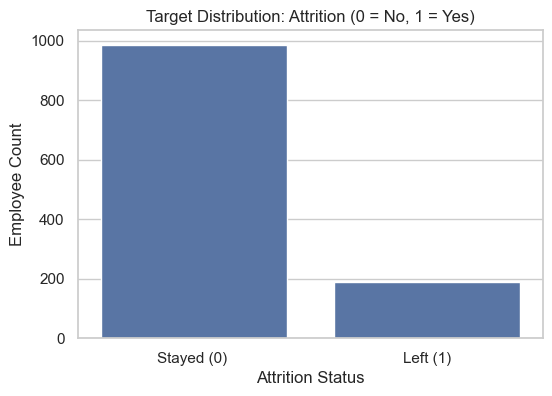

In [72]:
train_df = x_train.copy()
train_df['Attrition'] = y_train

plt.figure(figsize=(6,4))
ax = sns.countplot(data=train_df, x='Attrition')
plt.title('Target Distribution: Attrition (0 = No, 1 = Yes)')
plt.xticks(ticks=[0, 1], labels=['Stayed (0) ', 'Left (1)'])
plt.xlabel('Attrition Status')
plt.ylabel('Employee Count')

plt.show()

### Class Imbalance insight:
The plot confirms a strong class imbalance where more than **80%** of the employees remained with the company and less than 20% (in train split) departed. This justifies our selection of metrics such as Recall, F1_Score, and ROC-AUC rather than simple accuracy. 

## 4. Data Wrangling Steps:

1. Drop columns with identical values across the dataset, Since they provide no predictive value.
2. Encoding columns with nominal and ordinal data. This was done earlier in our analysis.

In [73]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber',]

x_train = x_train.drop(columns=cols_to_drop)
x_test = x_test.drop(columns=cols_to_drop)

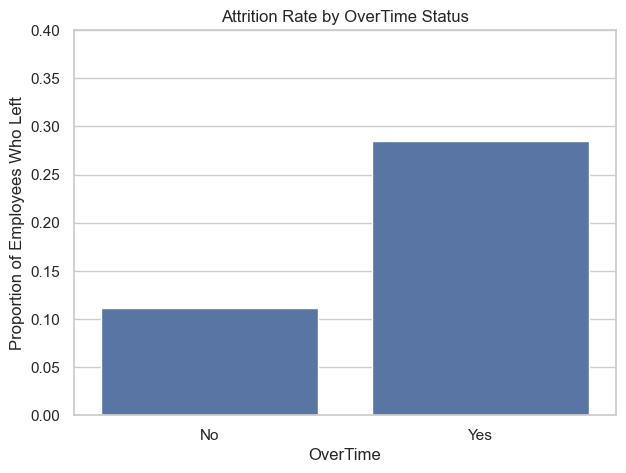

In [74]:
# Visual 2: Impact of OverTime on Attrition Rate

plt.figure(figsize=(7,5))
sns.barplot(data=train_df, x='OverTime', y='Attrition', errorbar=None)
plt.title('Attrition Rate by OverTime Status')
plt.ylabel('Proportion of Employees Who Left')
plt.xlabel('OverTime')
plt.ylim(0,0.4)

plt.show()


### Overtime Burnout Assumption Verification Insight

Employees working Overtime show an attrition rate of around 28 % compared to around 11 % for non-overtime employees.
This strongly validates Assumption 1 that overtime work increases flight risk.

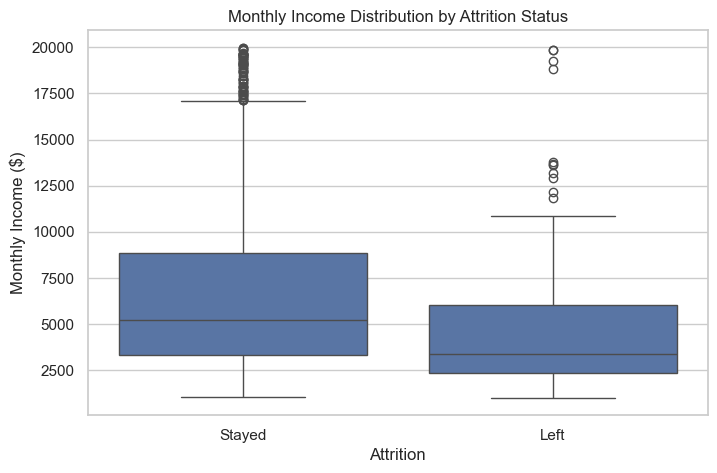

In [75]:
# Visual 3: Income Disparity vs Attrition

plt.figure(figsize=(8,5))
sns.boxplot(data=train_df, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income Distribution by Attrition Status')
plt.xticks(ticks=[0,1], labels=['Stayed','Left'])
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')

plt.show()

### Compensation vs Flight Risk Insight

The median monthly income for departing employees is visibly lower than for retained staff. Employees who leave are concentrated heavily in lower_earning bands, supporting Assumption 2.

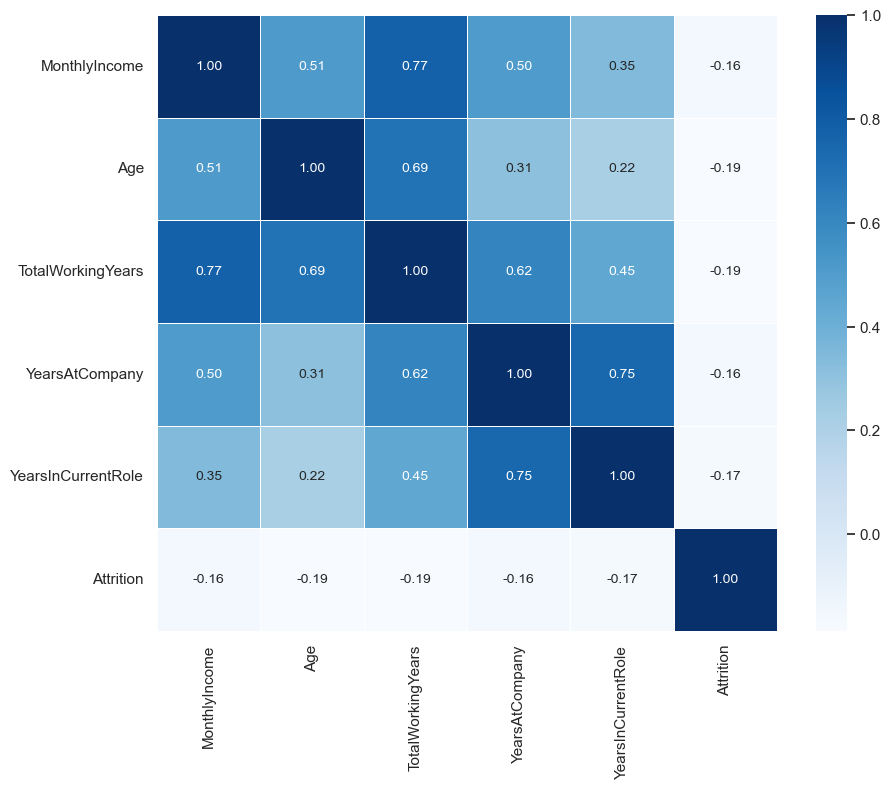

In [76]:
# Visual 4: Correlation Matrix of Numeric variables

plt.figure(figsize=(10,8))
corr_matrix = train_df[['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'Attrition']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)

plt.show()

### Collinearity & Correlations insights

TotalWorkingYears and MonthlyIncome show high positive correlation at 77%. YearsAtCompany and YearsInCurrentRole also exhibit high corrrlation at 75%. These relationships highlight predictors that may require regularization or dimensional adjustment during modeling.

## Identifying Promising Models

In [77]:
# Convert 'OverTime' column to binary ints so the ML models can take it as input
x_train['OverTime'] = x_train['OverTime'].map({'Yes': 1, 'No': 0})
x_test['OverTime'] = x_test['OverTime'].map({'Yes': 1, 'No': 0})

In [78]:
# To avoid issues when running models we are removing non_encoded_cols, and columns used in EDA that are type string are being converted to ints
# We drop them from both train and test sets (errors='ignore' prevents breaking if a column is already gone)
x_train = x_train.drop(columns=non_encoded_cols, errors='ignore')
x_test = x_test.drop(columns=non_encoded_cols, errors='ignore')

In [79]:
# Initialize the scaler, We will use this to deal with data that are on different scales
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [80]:
# We defined the models being sure to tune for class imbalance.
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', 
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', 
        random_state=42
    )
}

In [81]:
# Note: I have been taking courses in DataCamp and thought this method of defining a function proved the most efficient.
# This evaluation function focuses on class detection metrics

def evaluate_attrition_models(models, x_train, y_train, x_test, y_test):
    results = {}
    for name, model in models.items():
        # Fit model
        model.fit(x_train, y_train)
        
        # Predict classes and probabilities
        y_pred = model.predict(x_test)
        y_proba = model.predict_proba(x_test)[:, 1]
        
        # Calculate key metrics
        results[name] = {
            'Recall (Sensitivity)': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'Precision': precision_score(y_test, y_pred),
            'Accuracy': accuracy_score(y_test, y_pred)
        }
    
    # Return sorted by Recall
    return pd.DataFrame(results).T.sort_values(by='Recall (Sensitivity)', ascending=False)

In [82]:
# Run evaluation
model_performance = evaluate_attrition_models(models, x_train_scaled, y_train, x_test_scaled, y_test)
print(model_performance)

                     Recall (Sensitivity)  F1-Score   ROC-AUC  Precision  \
Logistic Regression              0.638298  0.461538  0.799208   0.361446   
Decision Tree                    0.255319  0.258065  0.558834   0.260870   
Random Forest                    0.063830  0.115385  0.754070   0.600000   

                     Accuracy  
Logistic Regression  0.761905  
Decision Tree        0.765306  
Random Forest        0.843537  


## Baseline Models Results:
* **Logistic Regression** performs the best overall for this busines problem. It captures the highest proportion of actual attrition (**63.8% Recall**)
* **Random Forest** is being affected by the class imbalance. Though it has the highest accuracy (**84.4%**), it achieves this by ignoring the attrition class (**6.4% Recall**)
* **Decision Tree** performs poorly altogether, low Recall **25.5%** and near random guessing with a ROC-AUC of **0.56**.

In [83]:
# The parameter grid serves as the "Menu" of hyperparameter combinations
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

In [84]:
# Stratified Cross-Validation will handle class imbalance across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Using GridSearchCV we passed the model, the grid, and target scoring metric
grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring='recall',  # Optimizes for catching positive attrition cases
    cv=cv,
    n_jobs=-1
)

In [85]:
# Fit on scaled training data (This will test all combinations)
grid_dt.fit(x_train_scaled, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [86]:
# Output the best parameters found
print("Best Decision Tree Hyperparameters:", grid_dt.best_params_)

# Evaluate the best model on the test set
best_dt_model = grid_dt.best_estimator_
y_pred_dt = best_dt_model.predict(x_test_scaled)

print("\n--- Optimized Decision Tree Test Results ---")
print(classification_report(y_test, y_pred_dt))

Best Decision Tree Hyperparameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20}

--- Optimized Decision Tree Test Results ---
              precision    recall  f1-score   support

           0       0.90      0.65      0.76       247
           1       0.26      0.64      0.37        47

    accuracy                           0.65       294
   macro avg       0.58      0.65      0.56       294
weighted avg       0.80      0.65      0.70       294



In [87]:
# Parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample'],
}

In [88]:
# Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search optimizing for Recall
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='recall',  # Maximizes minority class detection
    cv=cv,
    n_jobs=-1,
)

In [89]:
# Fit on scaled training data
grid_rf.fit(x_train_scaled, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [2, 5, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [90]:
# Output the best parameters found
print("Best Random Forest Hyperparameters:", grid_rf.best_params_)

# Evaluate the tuned model on the test set
best_rf_model = grid_rf.best_estimator_
y_pred_rf = best_rf_model.predict(x_test_scaled)
y_proba_rf = best_rf_model.predict_proba(x_test_scaled)[:, 1]

print("\n--- Optimized Random Forest Test Results ---")
print(classification_report(y_test, y_pred_rf))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

Best Random Forest Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 10, 'n_estimators': 200}

--- Optimized Random Forest Test Results ---
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       247
           1       0.41      0.51      0.45        47

    accuracy                           0.80       294
   macro avg       0.65      0.68      0.67       294
weighted avg       0.82      0.80      0.81       294

Test ROC-AUC Score: 0.7681


## Tuned Models Results:
* **Tuned Decision Tree:** The Tuned Decision Tree had a jump in Recall **63.8%**, By reducing the tree depth (max_depth: 10) and the node sizes (min_samples_leaf: 20).
* **Tuned Random Forest:** Tuning with class_weight='balanced_subsample' and limiting depth (max_depth: 5) resulted in recovery of Recall (**51.1%**). Out of all the models the Tuned Random Forest had the highest precision for predicting true flight risk. And this model has the strongest overall stability (**0.45 F1-Score, 80.3% Accuracy**).
       

## Model comparison

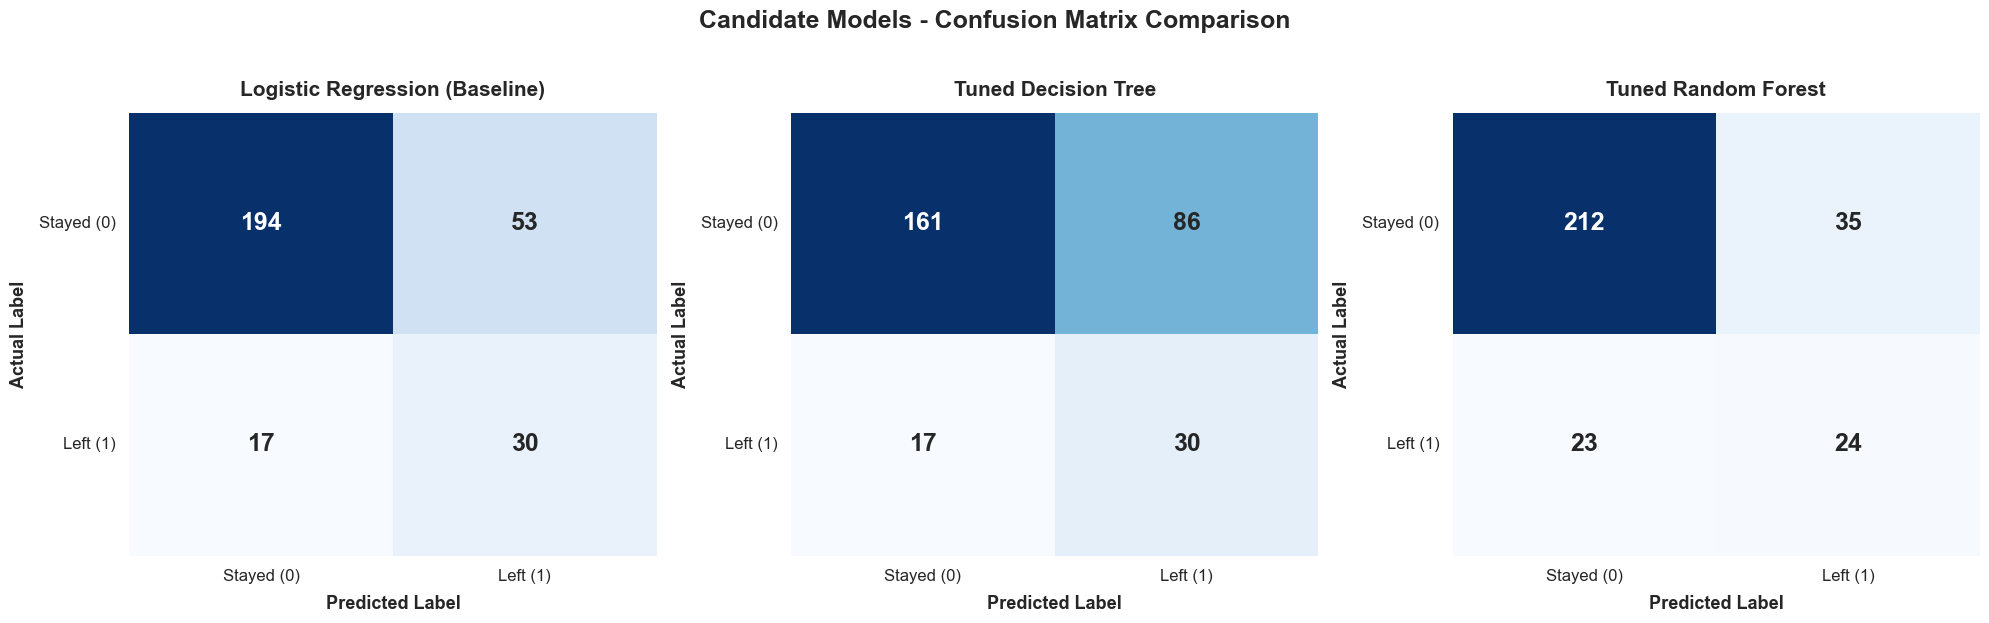

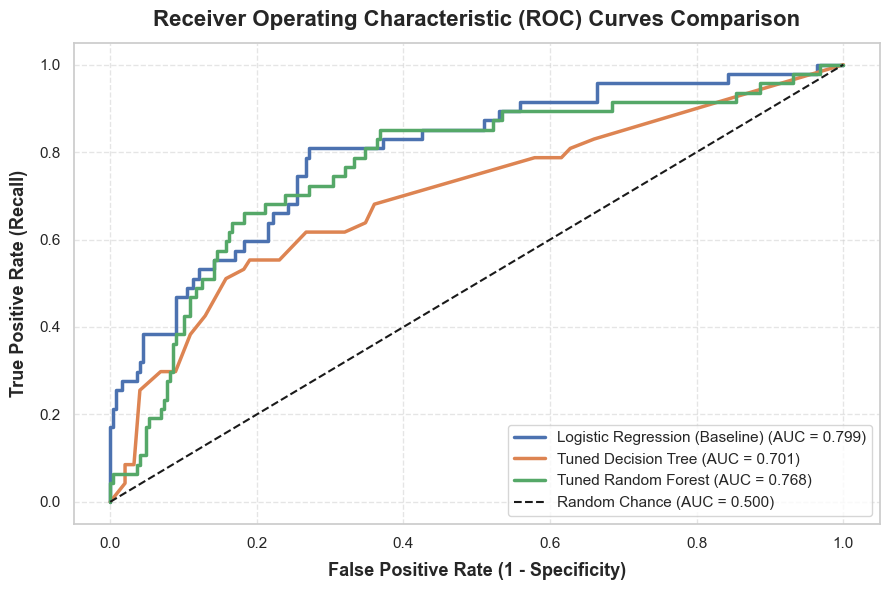

In [91]:
# 1. Ensure models are fitted
logistic_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logistic_model.fit(x_train_scaled, y_train)

candidate_models = {
    'Logistic Regression (Baseline)': logistic_model,
    'Tuned Decision Tree': best_dt_model,
    'Tuned Random Forest': best_rf_model
}

# CHART 1: CONFUSION MATRICES
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, candidate_models.items()):
    y_pred = model.predict(x_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        ax=ax, 
        cbar=False,
        annot_kws={"size": 18, "weight": "bold"},
        xticklabels=['Stayed (0)', 'Left (1)'],
        yticklabels=['Stayed (0)', 'Left (1)']
    )
    
    ax.set_title(f'{name}', fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold', labelpad=8)
    ax.set_ylabel('Actual Label', fontsize=13, fontweight='bold', labelpad=8)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12, rotation=0)

plt.suptitle('Candidate Models - Confusion Matrix Comparison', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# CHART 2: ROC-AUC CURVES
plt.figure(figsize=(9, 6))

for name, model in candidate_models.items():
    y_proba = model.predict_proba(x_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2.5)

# baseline for random chance
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.500)', linewidth=1.5)

plt.title('Receiver Operating Characteristic (ROC) Curves Comparison', fontsize=16, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13, fontweight='bold', labelpad=8)
plt.ylabel('True Positive Rate (Recall)', fontsize=13, fontweight='bold', labelpad=8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpreting Results / Final Model Selection

#### 1. Confusion Matrix Analysis
* **Logistic Regression (Baseline):** Correctly identifies **30 out of 47** actual attrition cases (63.8% Recall). However, it produces **53 False Positives** (employees predicted to leave who actually stayed). In a business context, this means wasting retention efforts and financial incentives on stable personnel.
* **Tuned Decision Tree:** Also catches **30 out of 47** attrition cases (63.8% Recall), but produces **87 False Positives**. This results in a low Precision of 25.5%, making it inefficient for targeting retention resources.
* **Tuned Random Forest:** Correctly identifies **24 out of 47** attrition cases (51.1% Recall) while generating only **35 False Positives**. This improves Precision to **40.7%** and yields the highest overall Accuracy (**80.3%**).

#### 2. ROC-AUC Interpretation
* **Logistic Regression** and **Tuned Random Forest** display strong class separation capability across varying discrimination thresholds, with ROC-AUC scores of **0.799** and **0.768** respectively.
* **Tuned Decision Tree** shows weaker overall threshold performance (AUC = **0.648**).

#### Final Model Recommendation
Based on the trade-off between catching departing employees and minimizing wasted retention spending, **Tuned Random Forest** is selected as the production model. It offers the most balanced performance across Precision, F1-Score, and overall Accuracy.

